# Méthodes de régression et classification d'arbres de décision

1) Régression par arbre de décision

2) Classification par arbres de décision

3) Forêts aléatoires, Bagging et Boosting

4) Validation croisée

In [29]:
import numpy as np
import pandas as pd
import patsy as pt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from IPython.display import HTML
try:
    from ipywidgets import interact
    import ipywidgets as widgets
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ipywidgets"])
    from ipywidgets import interact
    import ipywidgets as widgets
import copy
import warnings
warnings.filterwarnings('ignore')

from sklearn import tree
try:
    import graphviz
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "graphviz"])
    import graphviz

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn import datasets
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,confusion_matrix, classification_report

from sklearn.linear_model import Lasso
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier

from IPython.display import Image

try:
    import pydot
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pydot"])
    import pydot
from six import StringIO
try:
    import pydotplus
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pydotplus"])
    import pydotplus


%matplotlib inline
#plt.style.use('seaborn-white')

## 1) Régression par arbre de décision

Appliquons les forêts aléatoires aux données de Hitters en utilisant 3 noeuds

In [30]:
df = pd.read_csv('../../data/Hitters.csv').dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  263 non-null    object 
 1   AtBat       263 non-null    int64  
 2   Hits        263 non-null    int64  
 3   HmRun       263 non-null    int64  
 4   Runs        263 non-null    int64  
 5   RBI         263 non-null    int64  
 6   Walks       263 non-null    int64  
 7   Years       263 non-null    int64  
 8   CAtBat      263 non-null    int64  
 9   CHits       263 non-null    int64  
 10  CHmRun      263 non-null    int64  
 11  CRuns       263 non-null    int64  
 12  CRBI        263 non-null    int64  
 13  CWalks      263 non-null    int64  
 14  League      263 non-null    object 
 15  Division    263 non-null    object 
 16  PutOuts     263 non-null    int64  
 17  Assists     263 non-null    int64  
 18  Errors      263 non-null    int64  
 19  Salary      263 non-null    float6

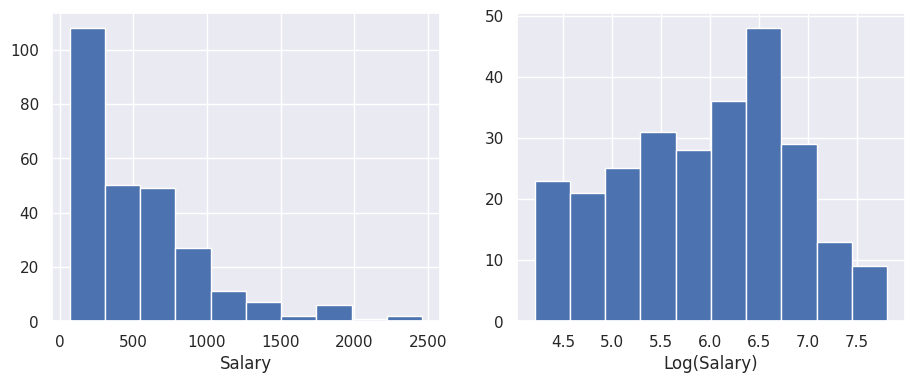

In [42]:
X = df[['Years', 'Hits']]
y = np.log(df.Salary)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(11,4))
ax1.hist(df.Salary)
ax1.set_xlabel('Salary')
ax2.hist(y)
ax2.set_xlabel('Log(Salary)');

### Arbre de décision

In [32]:
regrtree = DecisionTreeRegressor(max_leaf_nodes=3)
regrtree.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,3
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [33]:
text_representation = tree.export_text(regrtree)
print(text_representation)

|--- feature_0 <= 4.50
|   |--- value: [5.11]
|--- feature_0 >  4.50
|   |--- feature_1 <= 117.50
|   |   |--- value: [6.00]
|   |--- feature_1 >  117.50
|   |   |--- value: [6.74]



[Text(0.4, 0.8333333333333334, 'x[0] <= 4.5\nsquared_error = 0.788\nsamples = 263\nvalue = 5.927'),
 Text(0.2, 0.5, 'squared_error = 0.471\nsamples = 90\nvalue = 5.107'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= 117.5\nsquared_error = 0.42\nsamples = 173\nvalue = 6.354'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'squared_error = 0.312\nsamples = 90\nvalue = 5.998'),
 Text(0.8, 0.16666666666666666, 'squared_error = 0.252\nsamples = 83\nvalue = 6.74')]

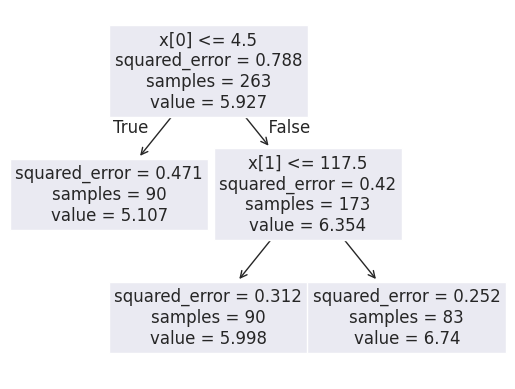

In [43]:
tree.plot_tree(regrtree)

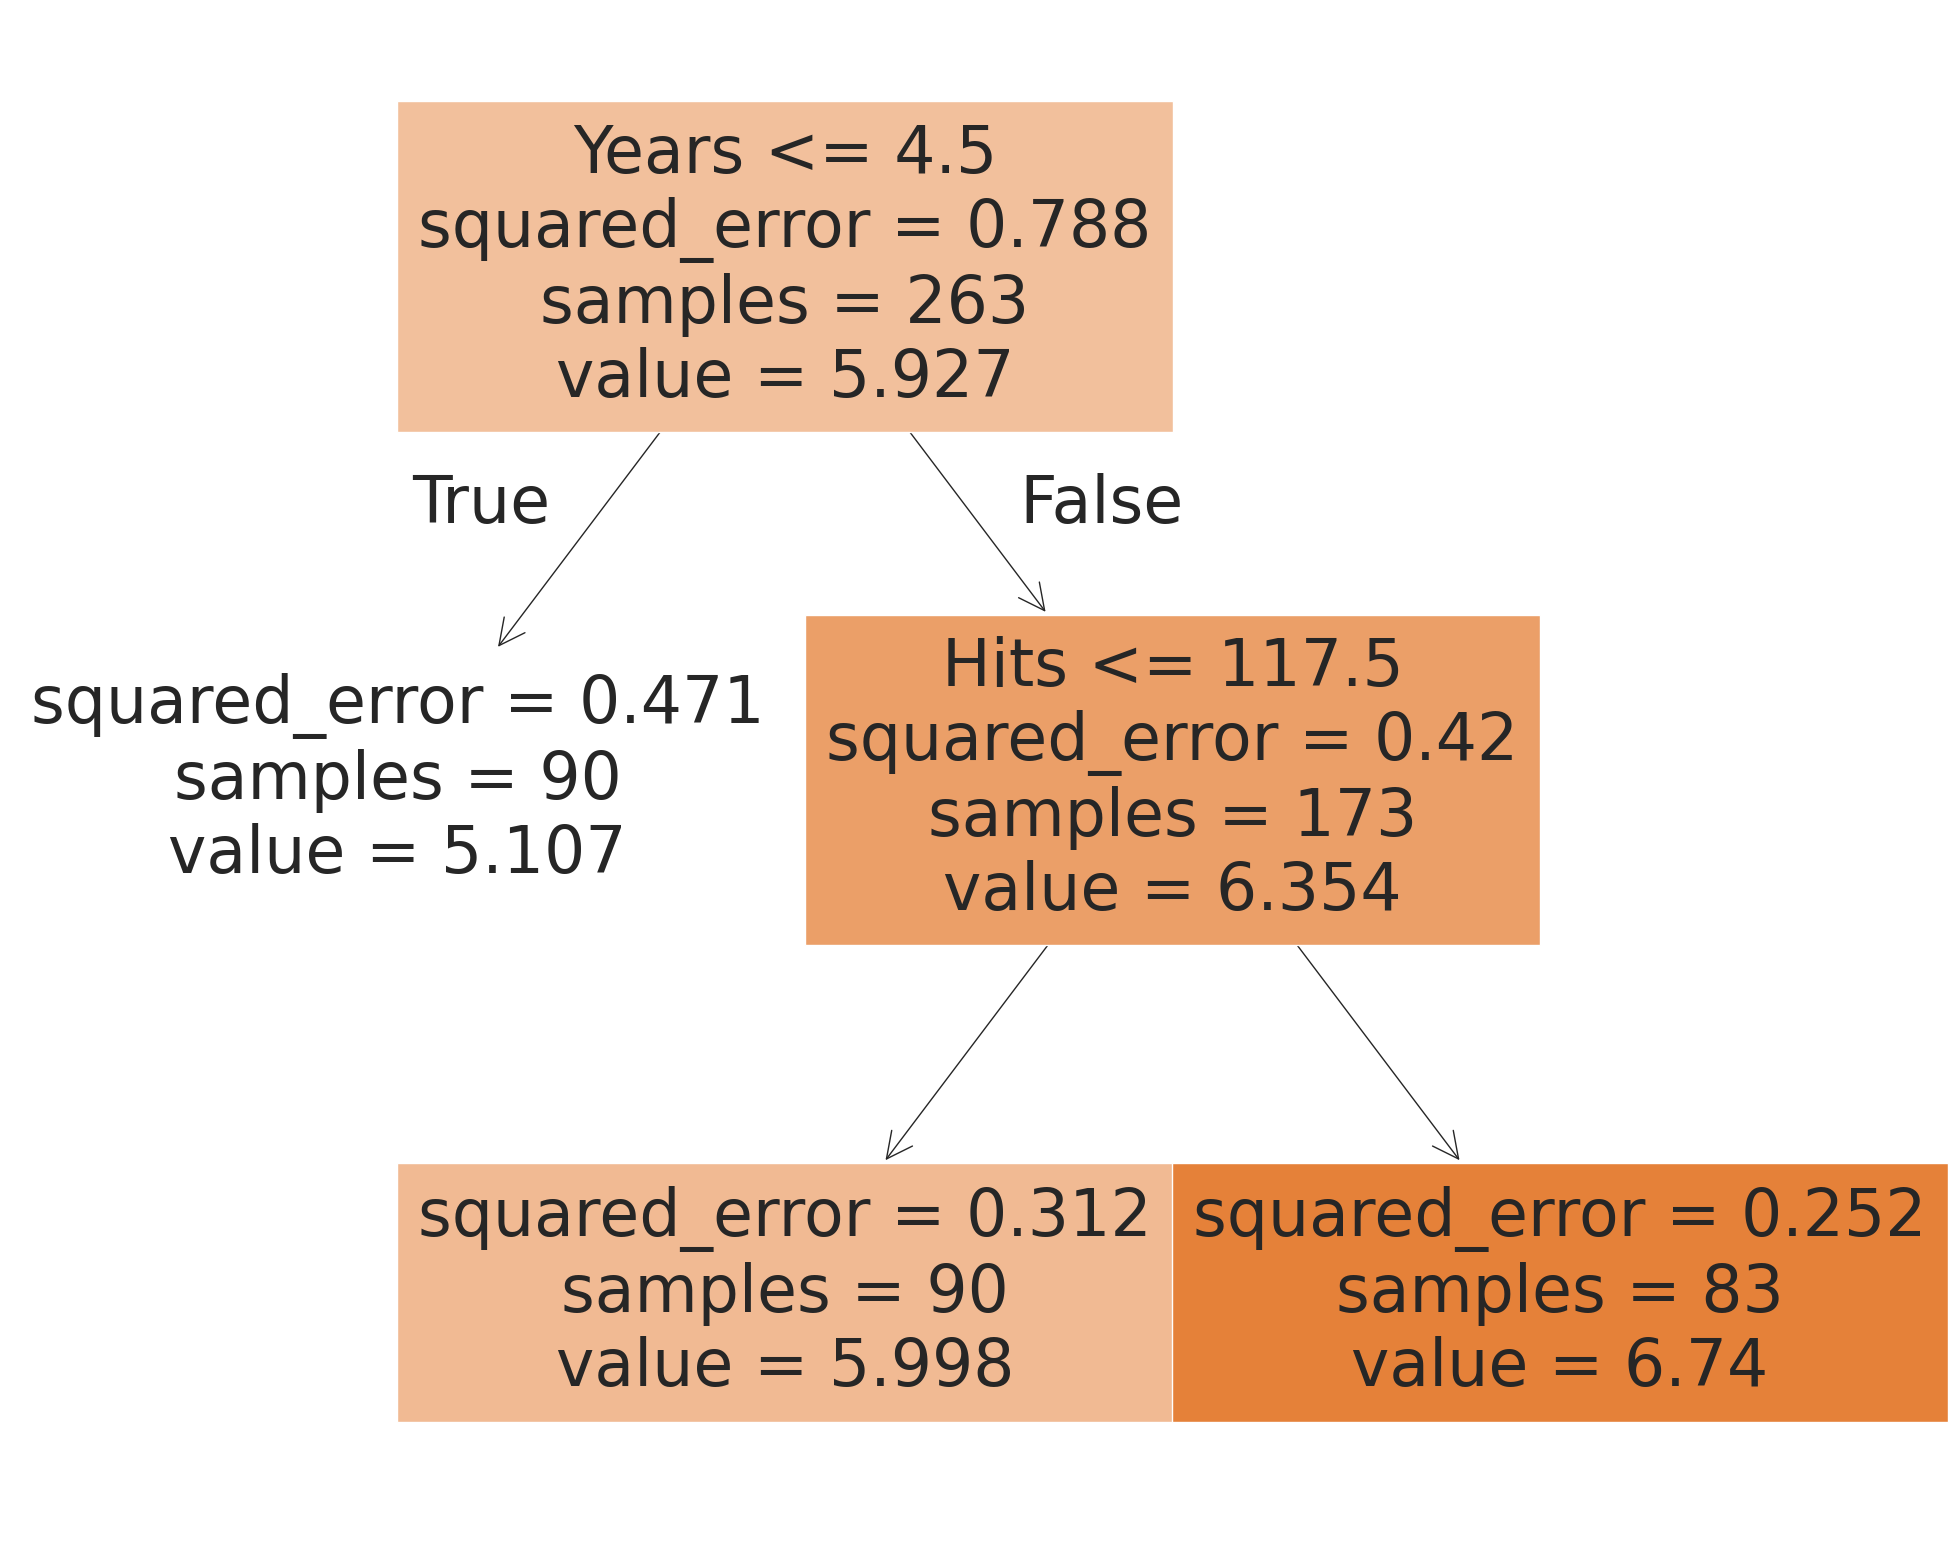

In [35]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(regrtree,
                   feature_names=['Years', 'Hits'],
                   class_names=['Salary'],
                   filled=True)

In [36]:

dot_data = StringIO()
export_graphviz(regrtree, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, feature_names=['Years', 'Hits'],
                   class_names=['Salary'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('tree.png')
Image(graph.create_png())

InvocationException: GraphViz's executables not found

In [37]:
# Cette fonction représente l'arbre avec pydot
def print_tree(estimator, features, class_names=None, filled=True):
    tree = estimator
    names = features
    color = filled
    classn = class_names

    dot_data = StringIO()
    export_graphviz(estimator, out_file=dot_data, feature_names=features, class_names=classn, filled=filled)
    graph = pydot.graph_from_dot_data(dot_data.getvalue())
    return(graph)

In [38]:
graph, = print_tree(regrtree, features=['Years', 'Hits'])
Image(graph.create_png())

FileNotFoundError: [Errno 2] "dot" not found in path.

In [39]:
help(tree._tree.Tree)

Help on class Tree in module sklearn.tree._tree:

class Tree(builtins.object)
 |  Array-based representation of a binary decision tree.
 |
 |  The binary tree is represented as a number of parallel arrays. The i-th
 |  element of each array holds information about the node `i`. Node 0 is the
 |  tree's root. You can find a detailed description of all arrays in
 |  `_tree.pxd`. NOTE: Some of the arrays only apply to either leaves or split
 |  nodes, resp. In this case the values of nodes of the other type are
 |  arbitrary!
 |
 |  Attributes
 |  ----------
 |  node_count : intp_t
 |      The number of nodes (internal nodes + leaves) in the tree.
 |
 |  capacity : intp_t
 |      The current capacity (i.e., size) of the arrays, which is at least as
 |      great as `node_count`.
 |
 |  max_depth : intp_t
 |      The depth of the tree, i.e. the maximum depth of its leaves.
 |
 |  children_left : array of intp_t, shape [node_count]
 |      children_left[i] holds the node id of the left chil

In [40]:
regrtree.tree_.node_count # noeuds et feuilles

5

In [41]:
regrtree.tree_.max_depth # max profondeur

2

#### Importance des variables

Hits     20.486748
Years    79.513252
dtype: float64


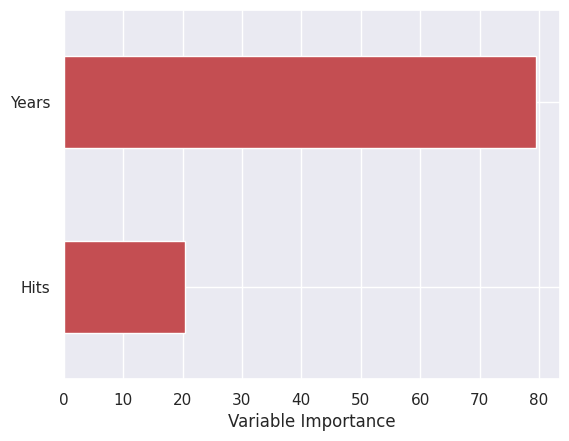

In [ ]:
# Importance des variables

feature_importance = regrtree.feature_importances_*100
rel_imp = pd.Series(feature_importance, index=X.columns).sort_values(inplace=False)
print(rel_imp)
rel_imp.T.plot(kind='barh', color='r', )
plt.xlabel('Variable Importance')
plt.gca().legend_ = None

Les régions de décision

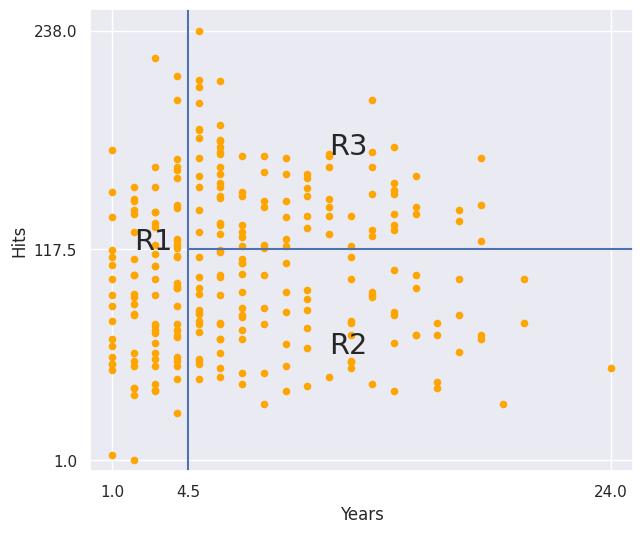

In [ ]:
df.plot('Years', 'Hits', kind='scatter', color='orange', figsize=(7,6))
plt.xlim(0,25)
plt.ylim(ymin=-5)
plt.xticks([1, 4.5, 24])
plt.yticks([1, 117.5, 238])
plt.vlines(4.5, ymin=-5, ymax=250)
plt.hlines(117.5, xmin=4.5, xmax=25)
plt.annotate('R1', xy=(2,117.5), fontsize='xx-large')
plt.annotate('R2', xy=(11,60), fontsize='xx-large')
plt.annotate('R3', xy=(11,170), fontsize='xx-large');

## 2) Classification par arbre de décision

Appliquons sur les données de Heart en utilisant 6 noeuds

In [ ]:
df2 = pd.read_csv('/content/Heart.csv').drop('Unnamed: 0', axis=1).dropna()
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        297 non-null    int64  
 1   Sex        297 non-null    int64  
 2   ChestPain  297 non-null    object 
 3   RestBP     297 non-null    int64  
 4   Chol       297 non-null    int64  
 5   Fbs        297 non-null    int64  
 6   RestECG    297 non-null    int64  
 7   MaxHR      297 non-null    int64  
 8   ExAng      297 non-null    int64  
 9   Oldpeak    297 non-null    float64
 10  Slope      297 non-null    int64  
 11  Ca         297 non-null    float64
 12  Thal       297 non-null    object 
 13  AHD        297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 34.8+ KB


In [ ]:
df2.ChestPain = pd.factorize(df2.ChestPain)[0]
df2.Thal = pd.factorize(df2.Thal)[0]

In [ ]:
X2 = df2.drop('AHD', axis=1)
y2 = pd.factorize(df2.AHD)[0]

In [ ]:
clf = DecisionTreeClassifier(max_depth=None, max_leaf_nodes=6, max_features=3)
clf.fit(X2,y2)

DecisionTreeClassifier(max_features=3, max_leaf_nodes=6)

In [ ]:
clf.score(X2,y2)

0.8282828282828283

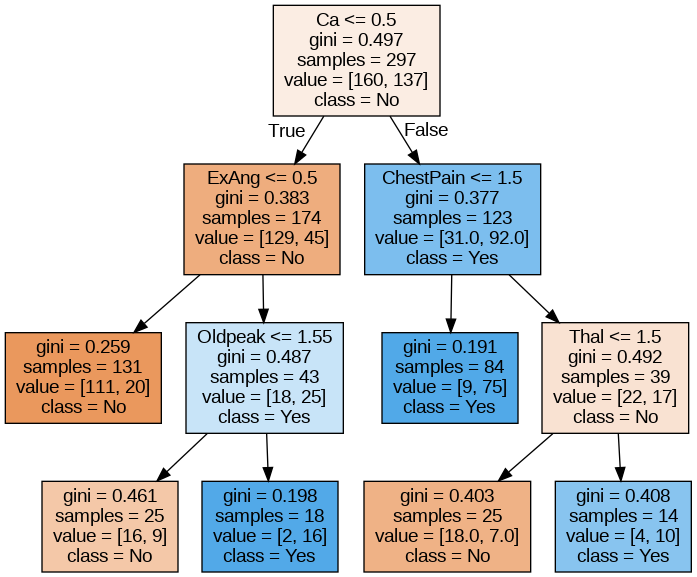

In [ ]:
graph2, = print_tree(clf, features=X2.columns, class_names=['No', 'Yes'])
Image(graph2.create_png())

#### Un autre exemple avec les données Carseats. Ajustons un arbre de classification afin de prédire High en utilisant toutes les variables sauf Sales.

In [ ]:
df3 = pd.read_csv('/content/Carseats.csv').drop('Unnamed: 0', axis=1)
df3.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [ ]:
df3['High'] = df3.Sales.map(lambda x: 1 if x>8 else 0)
df3.ShelveLoc = pd.factorize(df3.ShelveLoc)[0]
df3.High = pd.factorize(df3.High)[0]
df3.Urban = df3.Urban.map({'No':0, 'Yes':1})
df3.US = df3.US.map({'No':0, 'Yes':1})
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    int64  
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    int64  
 10  US           400 non-null    int64  
 11  High         400 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 37.6 KB


In [ ]:
df3.head(5)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,High
0,9.50,138,73,11,276,120,0,42,17,1,1,0
1,11.22,111,48,16,260,83,1,65,10,1,1,0
2,10.06,113,35,10,269,80,2,59,12,1,1,0
3,7.40,117,100,4,466,97,2,55,14,1,1,1
4,4.15,141,64,3,340,128,0,38,13,1,0,1


Arbre de classification afin de prédire High en utilisant toutes les variables sauf Sales.


In [ ]:
X = df3.drop(['Sales', 'High'], axis=1)
y = df3.High

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

In [ ]:
clf = DecisionTreeClassifier(max_depth=6)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=6)

In [ ]:
print(classification_report(y, clf.predict(X)))

              precision    recall  f1-score   support

           0       0.95      0.85      0.89       164
           1       0.90      0.97      0.93       236

    accuracy                           0.92       400
   macro avg       0.92      0.91      0.91       400
weighted avg       0.92      0.92      0.92       400



Figure de  l'arbre

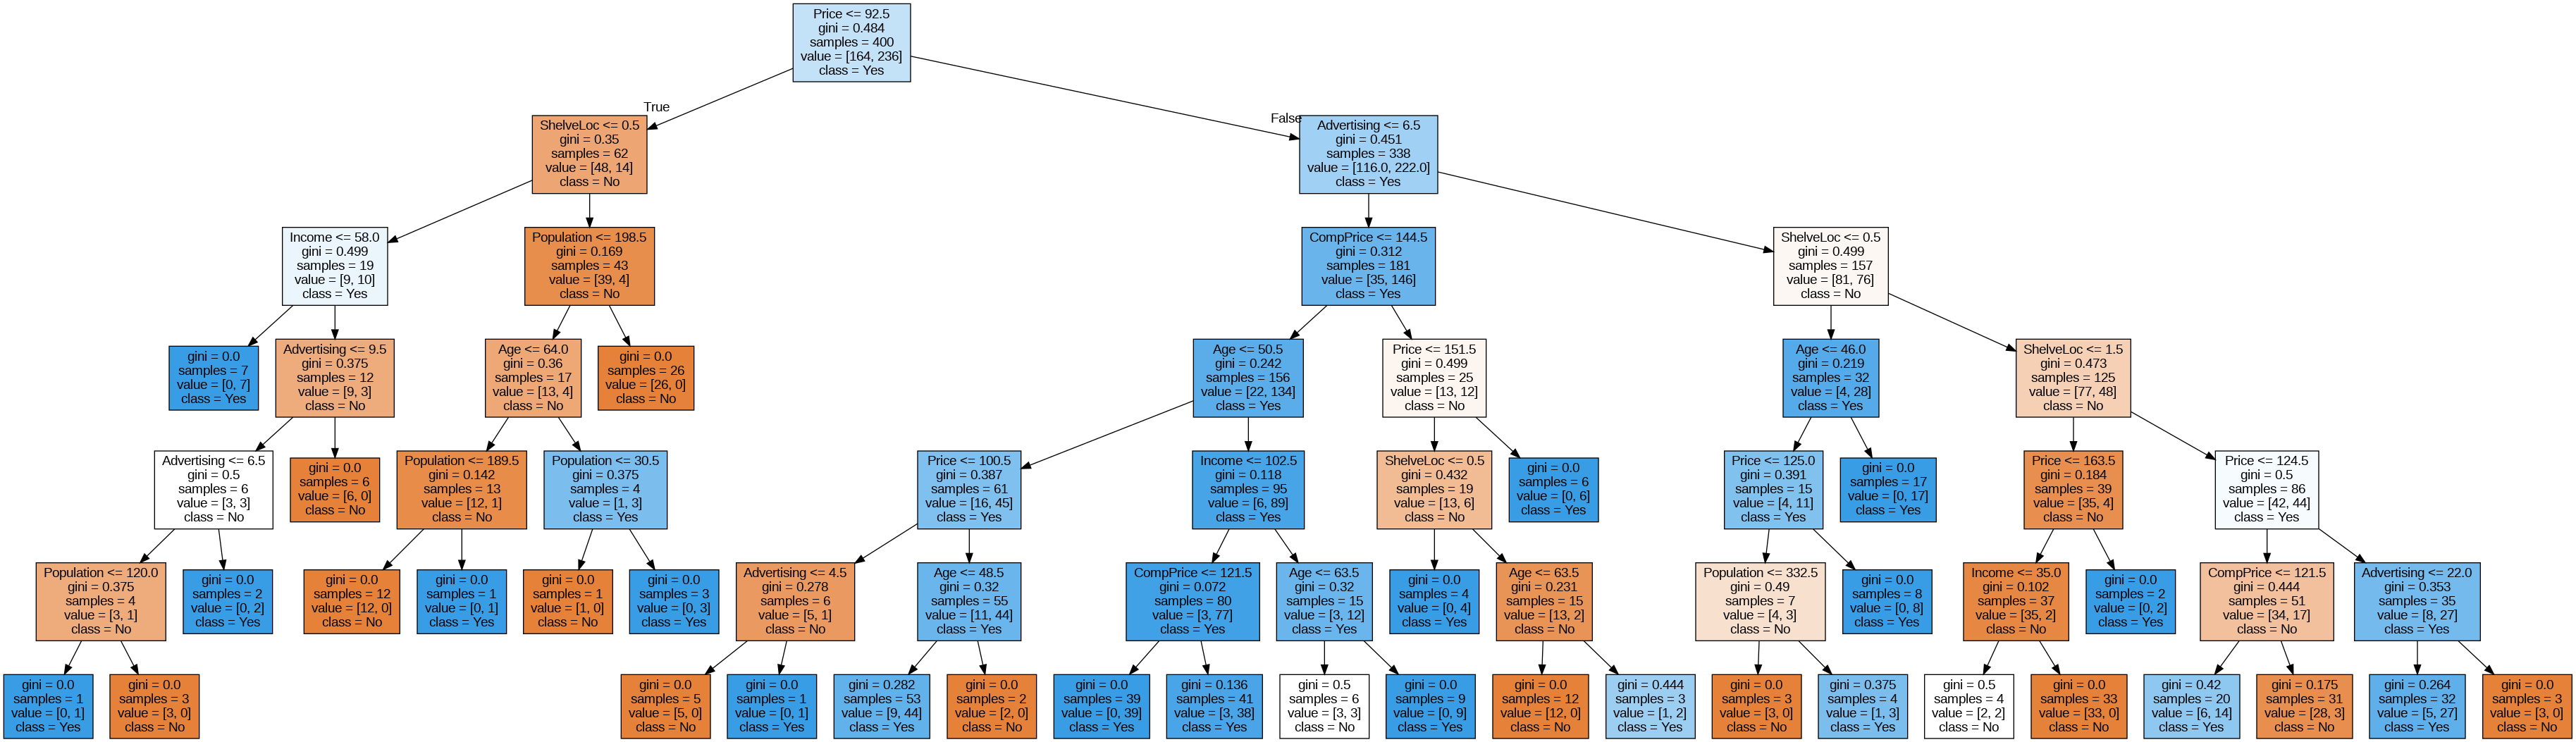

In [ ]:
graph3, = print_tree(clf, features=X.columns, class_names=['No', 'Yes'])
Image(graph3.create_png())

Afin d'évaluer correctement les performances de l'arbre calculons l'erreur de classification sur l'ensemble test

In [ ]:
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

In [ ]:
cm = pd.DataFrame(confusion_matrix(y_test, pred).T, index=['No', 'Yes'], columns=['No', 'Yes'])
cm.index.name = 'Predicted'
cm.columns.name = 'True'
cm

True,No,Yes
Predicted,,
No,50,19
Yes,32,99


In [ ]:
# Precision sur le test de 75%
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.72      0.61      0.66        82
           1       0.76      0.84      0.80       118

    accuracy                           0.74       200
   macro avg       0.74      0.72      0.73       200
weighted avg       0.74      0.74      0.74       200



## 3) Forets aléatoires, Bagging, Boosting

In [ ]:
boston_df = pd.read_csv('/content/Boston.csv')
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 55.5 KB


In [ ]:
X = boston_df.drop('medv', axis=1)
y = boston_df.medv

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

### Arbre avec profondeur max de 3

In [ ]:
# Choix de max depth à 3
regrb = DecisionTreeRegressor(max_depth=3)
regrb.fit(X_train, y_train)
pred = regrb.predict(X_test)

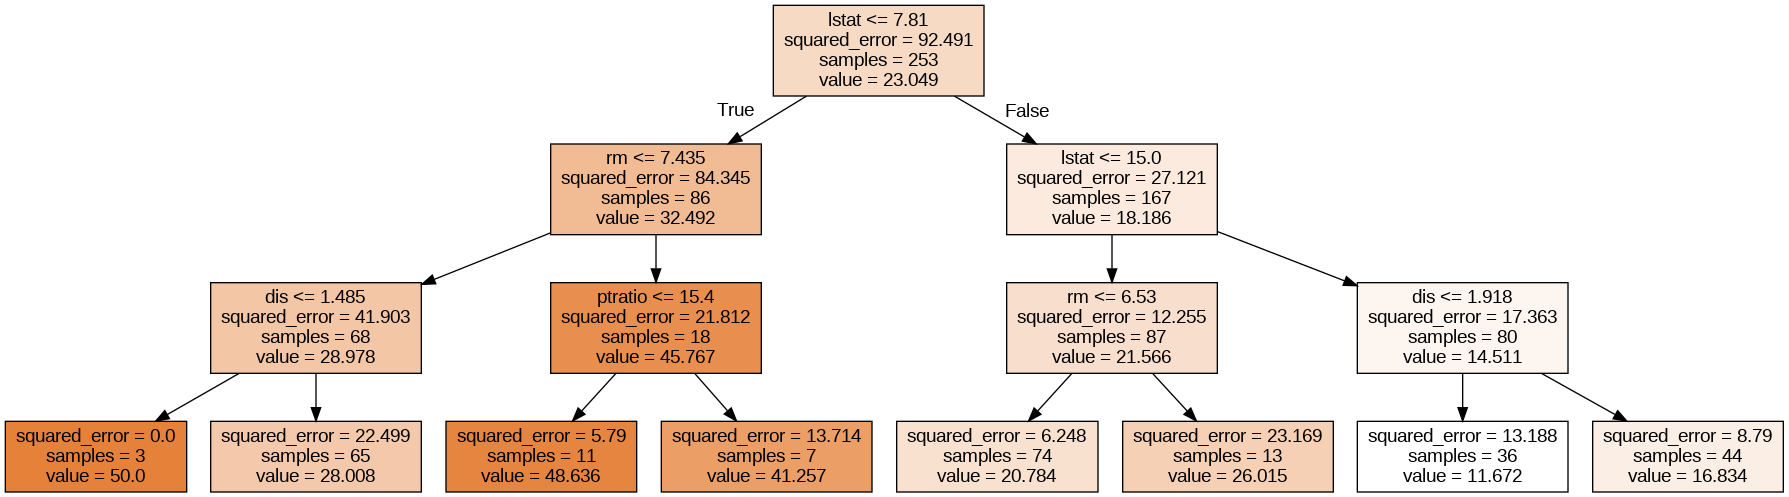

In [ ]:
graph, = print_tree(regrb, features=X.columns)
Image(graph.create_png())

Text(0, 0.5, 'y_test')

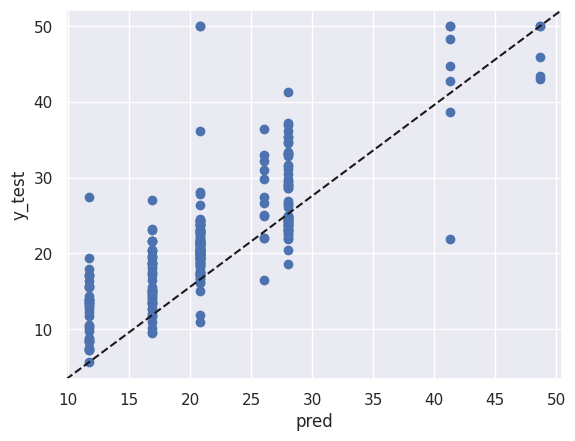

In [ ]:
plt.scatter(pred, y_test, label='medv')
plt.plot([0, 1], [0, 1], '--k', transform=plt.gca().transAxes)
plt.xlabel('pred')
plt.ylabel('y_test')

In [ ]:
mean_squared_error(y_test, pred)

26.02323085009744

In [ ]:
# Il y a 13 variables explicatives
X.shape

(506, 13)

#### Bagging

In [ ]:
# Bagging: avec toutes les variables
regr1 = RandomForestRegressor(max_features=13, random_state=1)
regr1.fit(X_train, y_train)

RandomForestRegressor(max_features=13, random_state=1)

Text(0, 0.5, 'y_test')

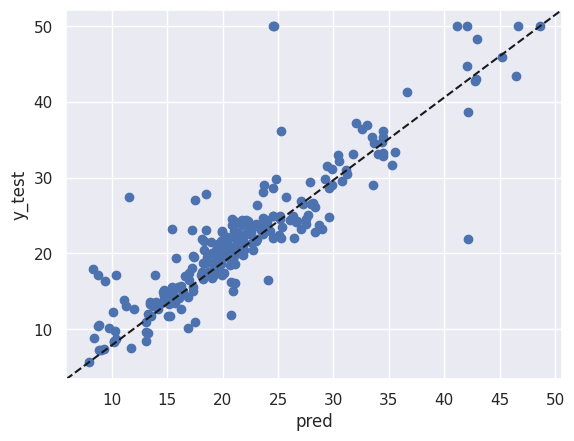

In [ ]:
pred = regr1.predict(X_test)

plt.scatter(pred, y_test, label='medv')
plt.plot([0, 1], [0, 1], '--k', transform=plt.gca().transAxes)
plt.xlabel('pred')
plt.ylabel('y_test')

In [ ]:
mean_squared_error(y_test, pred)

16.24916311462451

#### Forets aléatoires

In [ ]:
# Forets Random forests: using 6 features
regr2 = RandomForestRegressor(max_features=6, random_state=1)
regr2.fit(X_train, y_train)

RandomForestRegressor(max_features=6, random_state=1)

In [ ]:
pred = regr2.predict(X_test)
mean_squared_error(y_test, pred)

15.566582794466399

Importances des variables

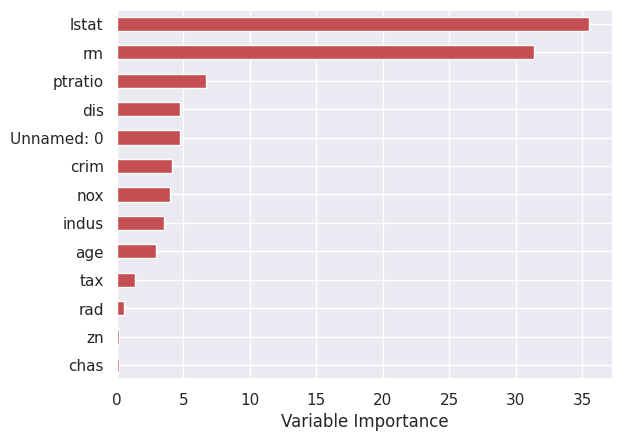

In [ ]:
Importance = pd.DataFrame({'Importance':regr2.feature_importances_*100}, index=X.columns)
Importance.sort_values('Importance', axis=0, ascending=True).plot(kind='barh', color='r', )
plt.xlabel('Variable Importance')
plt.gca().legend_ = None

### Boosting

In [ ]:
regr = GradientBoostingRegressor(n_estimators=500, learning_rate=0.01, random_state=1)
regr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01, n_estimators=500, random_state=1)

Importance des variables, LSTAT est la plus importante, zn est la moins importante

zn             0.014572
chas           0.058663
rad            0.107431
indus          0.400499
nox            0.746488
age            0.903613
tax            0.943797
crim           2.108504
Unnamed: 0     3.635967
ptratio        3.701663
dis            5.853500
rm            26.524579
lstat         55.000724
dtype: float64


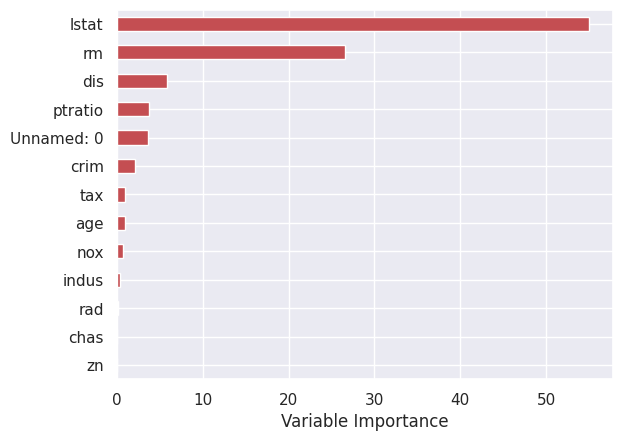

In [ ]:
feature_importance = regr.feature_importances_*100
rel_imp = pd.Series(feature_importance, index=X.columns).sort_values(inplace=False)
print(rel_imp)
rel_imp.T.plot(kind='barh', color='r', )
plt.xlabel('Variable Importance')
plt.gca().legend_ = None

In [ ]:
mean_squared_error(y_test, regr.predict(X_test))

15.256813921505488

## 4) Validation croisée

Utilisons la validation croisée (CV) pour comparer des arbres avec différents nombres de nœuds feuilles définis par le paramètre max_leaf_nodes peut être une approche utile pour évaluer la performance des arbres de décision. Voici comment vous pouvez procéder :

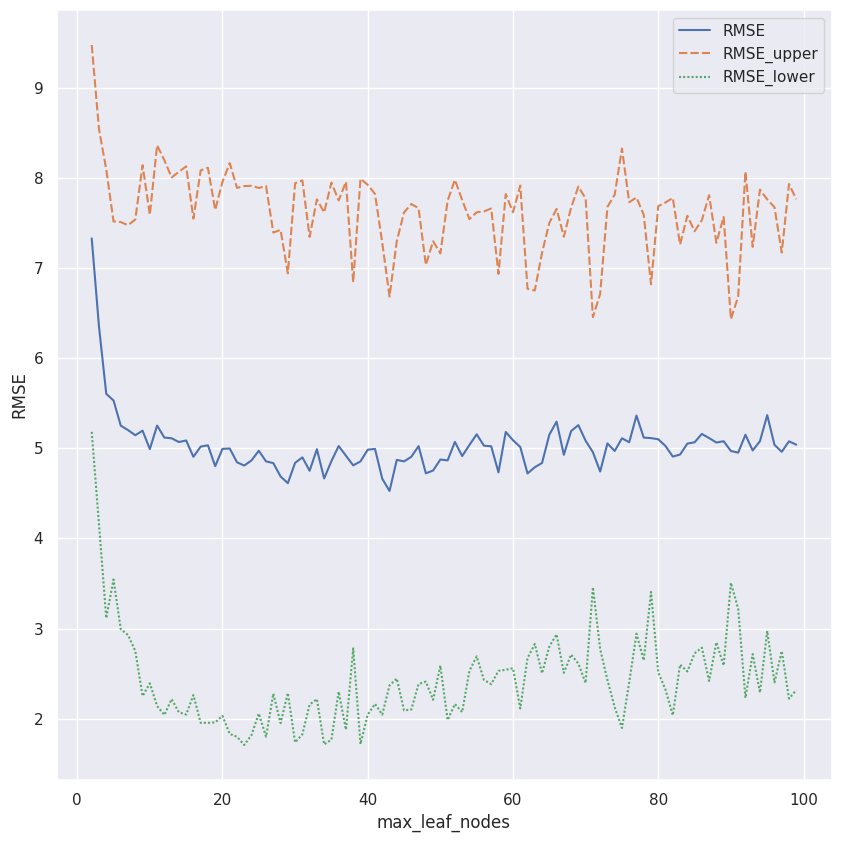

,RMSE,RMSE_upper,RMSE_lower
max_leaf_nodes,,,
43.0,4.527254,6.685968,2.368539


In [ ]:
tuning_param = 'max_leaf_nodes'
cv_folds = 5
columns=[tuning_param, 'RMSE', 'RMSE_upper', 'RMSE_lower']

results = []
for m in np.arange(2, 100):
    reg = tree.DecisionTreeRegressor(max_leaf_nodes=m)
    scores = cross_val_score(reg, X_train, y_train, cv=cv_folds, scoring='neg_mean_squared_error')
    rmses = np.sqrt(np.absolute(scores))
    rmse = np.mean(rmses)
    conf_int = np.std(rmses) *2
    results += [[m, rmse, rmse+conf_int, rmse-conf_int]]


# Plot RMSE regression en fonction
plot_df = pd.DataFrame(np.asarray(results), columns=columns).set_index(tuning_param)
plt.figure(figsize=(10,10))
sns.lineplot(data=plot_df)
plt.ylabel('RMSE')
plt.show();

# Choose model
choice = plot_df[plot_df['RMSE'] == plot_df['RMSE'].min()]
display(choice)

Ci-dessus, nous avons tracé la précision de la validation croisée pour un nombre croissant de nœuds feuilles. Environ 31 feuilles semblent être optimales. Le modèle semble légèrement surajuster à mesure que le nombre de feuilles augmente.
Remarquez qu'une approche alternative consiste à augmenter max_depth en tant que paramètre de réglage plus grossier.

In [ ]:
int(choice.index[0])

43

In [ ]:
reg = tree.DecisionTreeRegressor(max_leaf_nodes=int(choice.index[0])).fit(X_train, y_train)
y_hat = reg.predict(X_test)

rmse = np.sqrt(metrics.mean_squared_error(y_test, y_hat))
print('RMSE test: ${}'.format(int(rmse*1000)))

RMSE test: $5036


boston_df['Price'].median()*1000

In [ ]:
 boston_df['medv'].median()*1000

21200.0

Un RMSE de test de 5,151 est obtenu pour le modèle sélectionné, ce qui suggère que ce modèle peut prédire les prix des maisons avec une précision de ±5,151 de la vraie valeur d'une maison (21,200 dans cet ensemble de données).